# Retail Sales Data Cleaning & Analysis
**Dataset:** Retail Store Sales (Dirty) — Kaggle  
**Goal:** Clean messy retail transaction data and extract business insights  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
from pathlib import Path

# Set working directory to project root (works regardless of where Jupyter was launched)
notebook_dir = Path(os.getcwd())
project_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir
os.chdir(project_root)
print(f'Working directory: {os.getcwd()}')

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

os.makedirs('images', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

Working directory: C:\Users\Umut Cetin\Desktop\Python Projeler\retail-sales-data-cleaning


## 2. Load Data & Initial Inspection

In [2]:
df_raw = pd.read_csv('data/raw/retail_store_sales.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head(10)

Shape: (12575, 11)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.50,10.00,185.00,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.00,9.00,261.00,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.50,2.00,43.00,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.50,9.00,247.50,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.50,7.00,87.50,Digital Wallet,Online,2022-10-02,False
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.00,200.00,Credit Card,Online,2023-11-30,NaN
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.00,8.00,40.00,Credit Card,In-store,2023-06-10,True
7,TXN_1372952,CUST_21,Furniture,NaN,33.50,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.50,1.00,27.50,Credit Card,In-store,2023-04-26,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.50,3.00,109.50,Cash,Online,2024-03-14,False


In [3]:
print('--- Data Types ---')
print(df_raw.dtypes)
print('\n--- Basic Stats ---')
df_raw.describe(include='all')

--- Data Types ---
Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
Discount Applied     object
dtype: object

--- Basic Stats ---


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
count,12575,12575,12575,11362,11966.00,11971.00,11971.00,12575,12575,12575,8376
unique,12575,25,8,200,NaN,NaN,NaN,3,2,1114,2
top,TXN_6867343,CUST_05,Electric household essentials,Item_2_BEV,NaN,NaN,NaN,Cash,Online,2022-05-30,True
freq,1,544,1591,126,NaN,NaN,NaN,4310,6354,26,4219
mean,NaN,NaN,NaN,NaN,23.37,5.54,129.65,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,10.74,2.86,94.75,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,5.00,1.00,5.00,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,14.00,3.00,51.00,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,23.00,6.00,108.50,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,33.50,8.00,192.00,NaN,NaN,NaN,NaN


## 3. Missing Values — Before Cleaning

In [4]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Columns with missing values:')
print(missing_df)

Columns with missing values:
                  Missing Count  Missing %
Discount Applied           4199      33.39
Item                       1213       9.65
Price Per Unit              609       4.84
Quantity                    604       4.80
Total Spent                 604       4.80


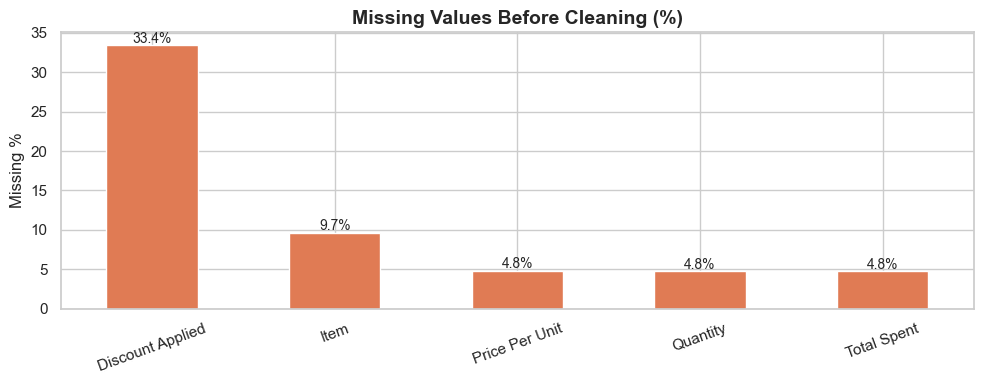

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
missing_df['Missing %'].plot(kind='bar', ax=ax, color='#e07b54', edgecolor='white')
ax.set_title('Missing Values Before Cleaning (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height() + 0.3),
                ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('images/missing_values_before.png', dpi=150)
plt.show()

## 4. Data Cleaning

In [6]:
df = df_raw.copy()
print(f'Original shape: {df_raw.shape}')
print(f'Working copy shape: {df.shape}')

Original shape: (12575, 11)
Working copy shape: (12575, 11)


### 4.1 Fix Data Types

In [7]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
# Discount Applied already contains boolean-like values (True, False, NaN)
# No mapping needed — missing values will be handled in step 4.4
print(df.dtypes)
print('\nDate range:', df['Transaction Date'].min(), '→', df['Transaction Date'].max())

Transaction ID              object
Customer ID                 object
Category                    object
Item                        object
Price Per Unit             float64
Quantity                   float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
Discount Applied            object
dtype: object

Date range: 2022-01-01 00:00:00 → 2025-01-18 00:00:00


### 4.2 Remove Duplicates

In [8]:
duplicate_rows = df.duplicated().sum()
duplicate_txn_ids = df['Transaction ID'].duplicated().sum()
print(f'Duplicate rows: {duplicate_rows}')
print(f'Duplicate Transaction IDs: {duplicate_txn_ids}')

df = df.drop_duplicates()
print(f'Shape after removing duplicates: {df.shape}')

Duplicate rows: 0
Duplicate Transaction IDs: 0
Shape after removing duplicates: (12575, 11)


### 4.3 Recover Missing Numeric Values

In [9]:
# In this dataset, only missing Price Per Unit values can be recovered.
# Missing Quantity and Total Spent cannot be recovered because they are missing together in the same rows.

mask_price = (
    df['Price Per Unit'].isnull() &
    df['Total Spent'].notnull() &
    df['Quantity'].notnull() &
    (df['Quantity'] != 0)
)
df.loc[mask_price, 'Price Per Unit'] = (
    df.loc[mask_price, 'Total Spent'] / df.loc[mask_price, 'Quantity']
).round(2)
print(f'Recovered Price Per Unit values: {mask_price.sum()}')

print('\nRemaining missing values after recovery:')
print(df[['Price Per Unit', 'Quantity', 'Total Spent']].isnull().sum())

Recovered Price Per Unit values: 609

Remaining missing values after recovery:
Price Per Unit      0
Quantity          604
Total Spent       604
dtype: int64


### 4.4 Handle Remaining Missing Values

In [10]:
df['Discount Applied'] = df['Discount Applied'].fillna(False).astype(bool)
df['Item'] = df['Item'].fillna('Unknown Item')

before_drop = df.shape[0]
df = df.dropna(subset=['Price Per Unit', 'Quantity', 'Total Spent'])
after_drop = df.shape[0]

print(f'Rows before drop: {before_drop}')
print(f'Rows after drop:  {after_drop}')
print(f'Rows removed:     {before_drop - after_drop}')

Rows before drop: 12575
Rows after drop:  11971
Rows removed:     604


### 4.5 Data Integrity Check — Total Spent Validation

In [11]:
df['Calculated Total'] = (df['Price Per Unit'] * df['Quantity']).round(2)
mismatch = (df['Total Spent'].round(2) != df['Calculated Total']).sum()
print(f'Number of mismatched rows: {mismatch}')
df = df.drop(columns='Calculated Total')

Number of mismatched rows: 0


### 4.6 Standardize Text Columns

In [12]:
for col in ['Category', 'Payment Method', 'Location']:
    df[col] = df[col].astype(str).str.strip().str.title()

# Item: strip only — .title() would break formats like 'Item_10_PAT'
df['Item'] = df['Item'].astype(str).str.strip()

print('Category values:', sorted(df['Category'].unique()))
print('Payment Method values:', sorted(df['Payment Method'].unique()))
print('Location values:', sorted(df['Location'].unique()))

Category values: ['Beverages', 'Butchers', 'Computers And Electric Accessories', 'Electric Household Essentials', 'Food', 'Furniture', 'Milk Products', 'Patisserie']
Payment Method values: ['Cash', 'Credit Card', 'Digital Wallet']
Location values: ['In-Store', 'Online']


## 5. Missing Values — After Cleaning

In [13]:
# Missing values after cleaning
missing_after = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().mean() * 100).round(2)
})

display(missing_after)

total_missing_after = df.isnull().sum().sum()

if total_missing_after == 0:
    print('All columns clean!')
else:
    print(f'Total missing values remaining: {total_missing_after}')

,Missing Count,Missing %
Transaction ID,0,0.00
Customer ID,0,0.00
Category,0,0.00
Item,0,0.00
Price Per Unit,0,0.00
Quantity,0,0.00
Total Spent,0,0.00
Payment Method,0,0.00
Location,0,0.00
Transaction Date,0,0.00


All columns clean!


,Before Cleaning (%),After Cleaning (%)
Discount Applied,33.39,0.00
Item,9.65,0.00
Price Per Unit,4.84,0.00
Quantity,4.80,0.00
Total Spent,4.80,0.00


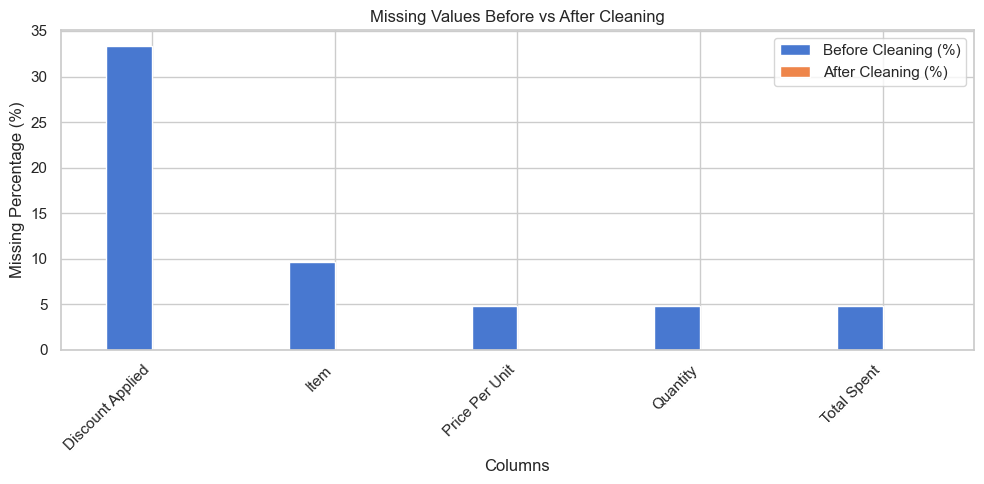

In [14]:
# Compare missing values before and after cleaning (same columns, side by side)
missing_before_pct = missing_df['Missing %']

missing_after_pct = (
    df[missing_before_pct.index]
    .isnull()
    .mean()
    .mul(100)
    .round(2)
)

missing_compare = pd.DataFrame({
    'Before Cleaning (%)': missing_before_pct,
    'After Cleaning (%)': missing_after_pct
})

display(missing_compare)

missing_compare.plot(kind='bar', figsize=(10, 5))
plt.title('Missing Values Before vs After Cleaning')
plt.xlabel('Columns')
plt.ylabel('Missing Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/missing_values_after.png', dpi=150, bbox_inches='tight')
plt.show()

After applying the cleaning steps, no missing values remain in the dataset. This confirms that all missing value handling strategies were successfully applied.

The before/after comparison shows that:
- Missing `Price Per Unit` values were recovered using the relationship between price, quantity, and total spent.
- Missing `Item` values were filled as `Unknown Item`.
- Missing `Discount Applied` values were filled with `False` based on the assumption that missing discount information means no discount was applied.
- Rows with unrecoverable numerical missing values were removed.

This validation step is important because data cleaning should always be followed by a quality check. Instead of assuming the dataset is clean, we verify it with code.

## 6. Analysis & Visualizations

### 6.1 Revenue by Category

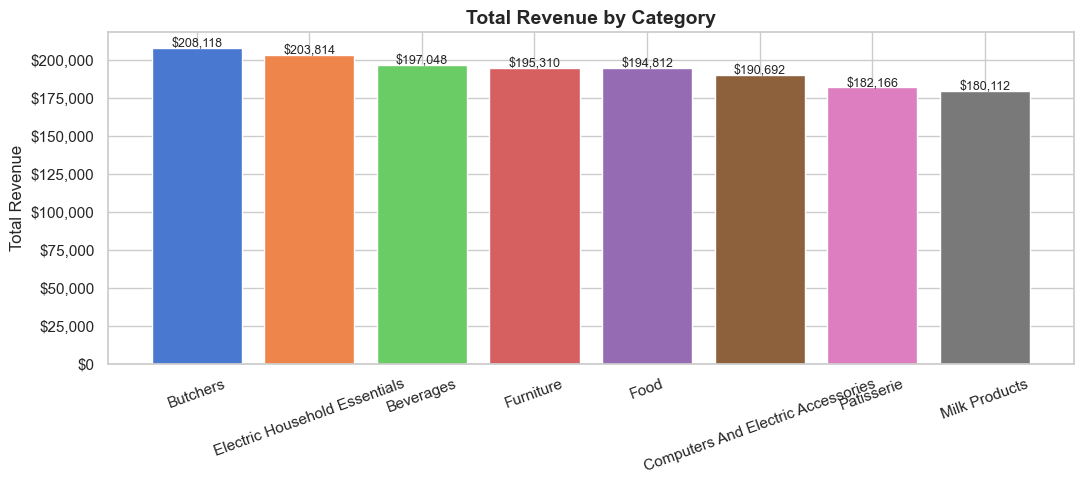

In [15]:
revenue_cat = df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(revenue_cat.index, revenue_cat.values,
              color=sns.color_palette('muted', len(revenue_cat)), edgecolor='white')
ax.set_title('Total Revenue by Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Revenue')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f'${bar.get_height():,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('images/revenue_by_category.png', dpi=150)
plt.show()

### 6.2 Top 10 Products by Revenue

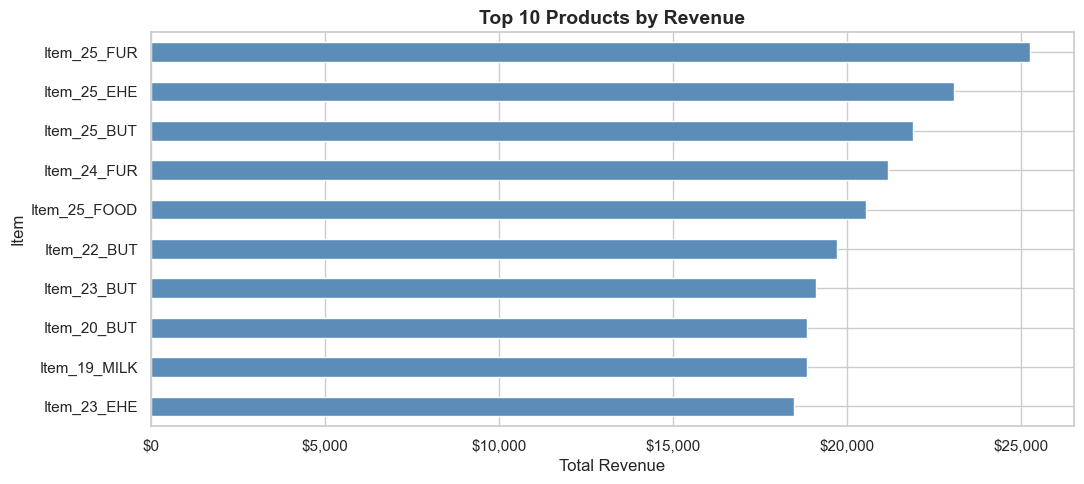

In [16]:
top_products = df[df['Item'] != 'Unknown Item'].groupby('Item')['Total Spent'].sum().nlargest(10)

fig, ax = plt.subplots(figsize=(11, 5))
top_products.sort_values().plot(kind='barh', ax=ax, color='#5b8db8', edgecolor='white')
ax.set_title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('images/revenue_by_product.png', dpi=150)
plt.show()

### 6.3 Monthly Sales Trend

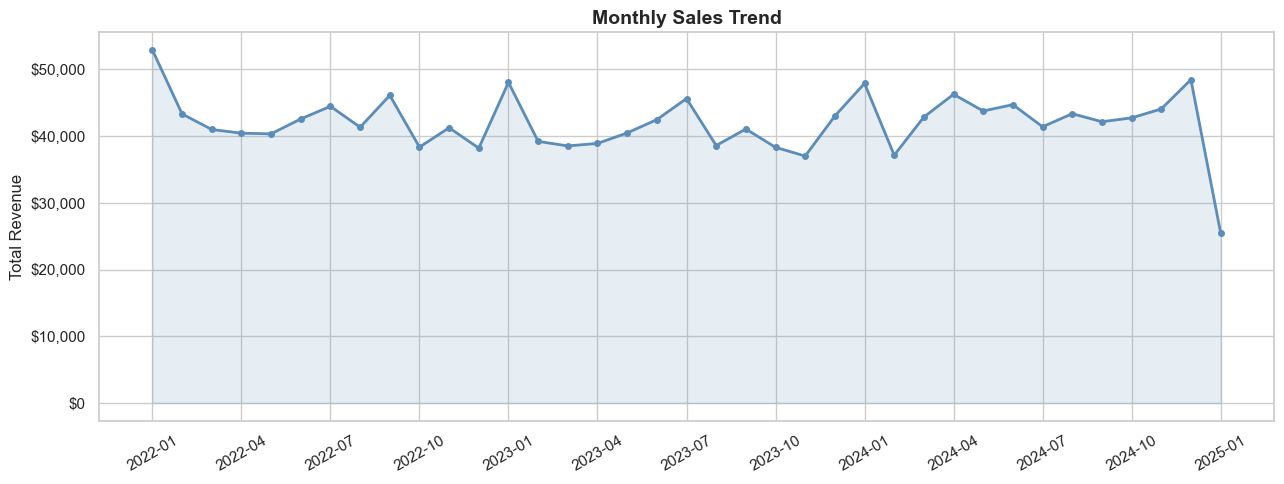

In [17]:
df['YearMonth'] = df['Transaction Date'].dt.to_period('M')
monthly = df.groupby('YearMonth')['Total Spent'].sum()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly.index.astype(str), monthly.values,
        marker='o', color='#5b8db8', linewidth=2, markersize=4)
ax.fill_between(monthly.index.astype(str), monthly.values, alpha=0.15, color='#5b8db8')
ax.set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Revenue')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
step = max(1, len(monthly) // 12)
ticks = list(range(0, len(monthly), step))
ax.set_xticks(ticks)
ax.set_xticklabels([monthly.index.astype(str)[i] for i in ticks], rotation=30)
plt.tight_layout()
plt.savefig('images/sales_trend.png', dpi=150)
plt.show()

## 7. Export Cleaned Data

In [18]:
csv_path = 'data/processed/retail_sales_cleaned.csv'
excel_path = 'outputs/retail_sales_summary.xlsx'

export_df = df.drop(columns=['YearMonth'], errors='ignore')

export_df.to_csv(csv_path, index=False)
export_df.to_excel(excel_path, index=False, sheet_name='Cleaned Data')

print(f'Cleaned data exported: {export_df.shape[0]} rows, {export_df.shape[1]} columns')
print(f'CSV saved to: {csv_path}')
print(f'Excel saved to: {excel_path}')
print("CSV exists:", os.path.exists(csv_path))
print("Excel exists:", os.path.exists(excel_path))

Cleaned data exported: 11971 rows, 11 columns
CSV saved to: data/processed/retail_sales_cleaned.csv
Excel saved to: outputs/retail_sales_summary.xlsx
CSV exists: True
Excel exists: True


After completing the data cleaning and validation steps, the cleaned dataset was exported for future use.

The cleaned data was saved in two formats:

- CSV format under `data/processed/`
- Excel format under `outputs/`

The CSV file is useful for reproducible data workflows, while the Excel file is useful for non-technical stakeholders who may prefer spreadsheet-based review.

The temporary `YearMonth` column was removed before export because it was created only for monthly trend analysis and is not part of the original cleaned dataset.

## 8. Cleaning Summary

In [19]:
summary = {
    'Metric': [
        'Raw rows',
        'Cleaned rows',
        'Rows dropped',
        'Duplicates removed',
        'Price Per Unit recovered',
        'Discount Applied filled',
        'Item filled (Unknown Item)',
        'Remaining missing values'
    ],
    'Value': [
        df_raw.shape[0],
        export_df.shape[0],
        df_raw.shape[0] - export_df.shape[0],
        duplicate_rows,
        int(mask_price.sum()),
        int(df_raw['Discount Applied'].isnull().sum()),
        int(df_raw['Item'].isnull().sum()),
        int(export_df.isnull().sum().sum())
    ]
}

summary_df = pd.DataFrame(summary)
summary_df.to_csv('outputs/cleaning_summary.csv', index=False)
print(summary_df.to_string(index=False))

                    Metric  Value
                  Raw rows  12575
              Cleaned rows  11971
              Rows dropped    604
        Duplicates removed      0
  Price Per Unit recovered    609
   Discount Applied filled   4199
Item filled (Unknown Item)   1213
  Remaining missing values      0


## Cleaning Results

| Step | Action |
|---|---|
| Data Types | Transaction Date → datetime, Discount Applied → bool |
| Duplicates | Checked; no duplicate rows or duplicate Transaction IDs were found |
| Price Per Unit | Recovered using Total Spent / Quantity where both were available |
| Discount Applied | Missing values filled with  |
| Item | Missing values filled with  |
| Unrecoverable rows | Dropped (Quantity or Total Spent missing together — not recoverable) |
| Integrity check | Total Spent validated against Price Per Unit × Quantity |

In [20]:
# Generate reports/summary_report.md
import os

rows_raw = df_raw.shape[0]
rows_clean = export_df.shape[0]
rows_dropped = rows_raw - rows_clean

lines = [
    '# Retail Sales Data Cleaning - Summary Report',
    '',
    '## Dataset',
    '- **Source:** Retail Store Sales (Dirty) - Kaggle',
    f'- **Raw rows:** {rows_raw:,}',
    f'- **Cleaned rows:** {rows_clean:,}',
    f'- **Columns:** {df_raw.shape[1]}',
    '',
    '## Cleaning Steps',
    '',
    '| Step | Action |',
    '|---|---|',
    '| Data Types | Transaction Date converted to datetime, Discount Applied to bool |',
    f'| Duplicates | {duplicate_rows} duplicate rows found and removed |',
    f'| Price Per Unit | {int(mask_price.sum())} missing values recovered via Total Spent / Quantity |',
    f'| Discount Applied | {int(df_raw["Discount Applied"].isnull().sum())} missing values filled with False |',
    f'| Item | {int(df_raw["Item"].isnull().sum())} missing values filled with Unknown Item |',
    f'| Rows dropped | {rows_dropped} rows dropped (unrecoverable missing Quantity/Total Spent) |',
    '| Data integrity | Total Spent validated against Price Per Unit x Quantity |',
    '| Text standardization | Category, Payment Method, Location standardized with .title() |',
    '',
    '## Result',
    '',
    f'- **Rows removed:** {rows_dropped:,}',
    f'- **Final dataset:** {rows_clean:,} clean rows',
    f'- **Remaining missing values:** {int(export_df.isnull().sum().sum())}',
    '',
    '## Exports',
    '- `data/processed/retail_sales_cleaned.csv`',
    '- `outputs/retail_sales_summary.xlsx`',
    '- `outputs/cleaning_summary.csv`',
]

os.makedirs('../reports', exist_ok=True)
with open('../reports/summary_report.md', 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))

print('summary_report.md generated.')


summary_report.md generated.
